In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import *

In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df['target'] = (df['Spending Score (1-100)'] > 50).astype(int)

In [4]:
df['Genre'] = df['Genre'].map({'Male': 0, 'Female': 1})

In [5]:
df

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),target
0,1,0,19,15,39,0
1,2,0,21,15,81,1
2,3,1,20,16,6,0
3,4,1,23,16,77,1
4,5,1,31,17,40,0
...,...,...,...,...,...,...
195,196,1,35,120,79,1
196,197,1,45,126,28,0
197,198,0,32,126,74,1
198,199,0,32,137,18,0


In [6]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
target                    0
dtype: int64

In [7]:
X = df[['Age', 'Annual Income (k$)']]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [10]:
y_pred = model.predict(X_test)

In [11]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Confusion Matrix:
 [[17  6]
 [ 6 11]]
Accuracy: 0.7


In [12]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.74      0.74        23
           1       0.65      0.65      0.65        17

    accuracy                           0.70        40
   macro avg       0.69      0.69      0.69        40
weighted avg       0.70      0.70      0.70        40



In [13]:
accuracies = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

print(accuracies)

[0.65, 0.55, 0.725, 0.7, 0.7, 0.7, 0.675, 0.675, 0.675, 0.675, 0.7, 0.675, 0.625, 0.725, 0.725, 0.725, 0.675, 0.65, 0.625, 0.65]


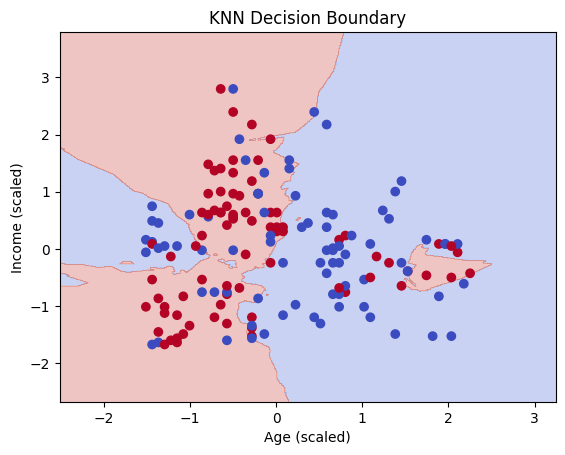

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Use only 2 features (already done: Age & Income)
X_set, y_set = X_train, y_train

# Create mesh grid
x1_min, x1_max = X_set[:, 0].min() - 1, X_set[:, 0].max() + 1
x2_min, x2_max = X_set[:, 1].min() - 1, X_set[:, 1].max() + 1

xx1, xx2 = np.meshgrid(
    np.arange(x1_min, x1_max, 0.01),
    np.arange(x2_min, x2_max, 0.01)
)

# Predict on grid
Z = model.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
Z = Z.reshape(xx1.shape)

# Plot
plt.contourf(xx1, xx2, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, cmap='coolwarm')

plt.title("KNN Decision Boundary")
plt.xlabel("Age (scaled)")
plt.ylabel("Income (scaled)")
plt.show()

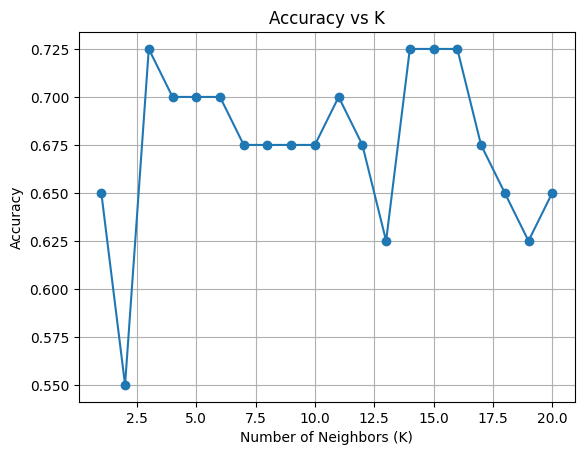

In [15]:
import matplotlib.pyplot as plt

k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

# Plot graph
plt.plot(k_values, accuracies, marker='o')
plt.title("Accuracy vs K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

C:\Users\Indian\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Predicted Class: 1


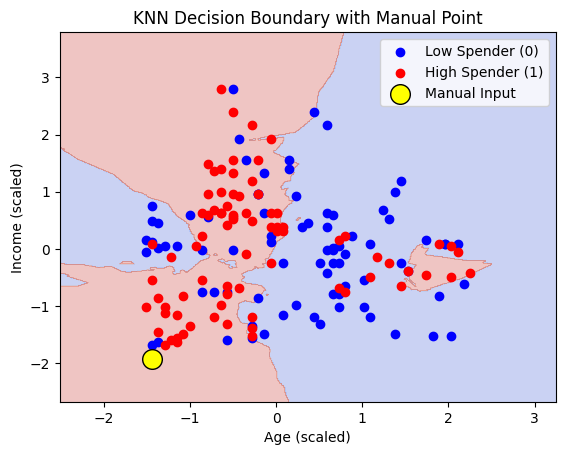

In [38]:
manual_point = np.array([[19, 8]])
manual_point_scaled = scaler.transform(manual_point)
predicted_class = model.predict(manual_point_scaled)
print("Predicted Class:", predicted_class[0])

X_set = np.array(X_train)
y_set = np.array(y_train)

x1_min, x1_max = X_set[:, 0].min() - 1, X_set[:, 0].max() + 1
x2_min, x2_max = X_set[:, 1].min() - 1, X_set[:, 1].max() + 1
xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, 0.01),
                       np.arange(x2_min, x2_max, 0.01))

Z = model.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)

plt.contourf(xx1, xx2, Z, alpha=0.3, cmap='coolwarm')

plt.scatter(X_set[y_set==0, 0], X_set[y_set==0, 1], color='blue', label='Low Spender (0)')
plt.scatter(X_set[y_set==1, 0], X_set[y_set==1, 1], color='red', label='High Spender (1)')

plt.scatter(manual_point_scaled[:, 0], manual_point_scaled[:, 1],
            color='yellow', edgecolor='black', s=200, label='Manual Input')

plt.xlabel("Age (scaled)")
plt.ylabel("Income (scaled)")
plt.title("KNN Decision Boundary with Manual Point")
plt.legend()
plt.show()